## **Quantum Circuit Mapping**

In [113]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer, AerSimulator
from qiskit_aer.primitives import SamplerV2
from qiskit import QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit import QuantumCircuit, Parameter, ParameterVector
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import generate_preset_pass_manager 
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import bluequbit
import numpy as np
import matplotlib.pylab as plt
import warnings
warnings.filterwarnings('ignore')
bq_client = bluequbit.init("EVWv3LhwF7bQSkRSHeMMwba6YJgB9Oi0")


[BQ-PYTHON-SDK][WARNING] - Beta version 0.18.4b1 of BlueQubit Python SDK is being used.


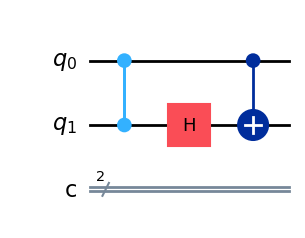

In [136]:
qc = QuantumCircuit(2,2)
c = 0
t = 1
qc.cz(c,t)
qc.h(t)
qc.cx(c,t)
qc.measure_all
qc.draw('mpl')


In [92]:
job = bq_client.run(qc, device="mps.cpu")
state_vector = job.get_counts()

[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: ihj5riTC3oxyI47e, device: mps.cpu, run status: RUNNING, created on: 2026-03-29 18:12:20 UTC, estimated runtime: 5000 ms, estimated cost: $0.00, num qubits: 2, shots: 1024


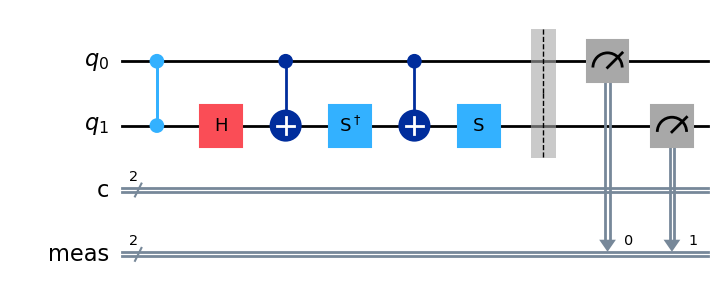

In [93]:
qc.sdg(t)
qc.cx(c,t)
qc.s(t)
qc.measure_all()
qc.draw('mpl')

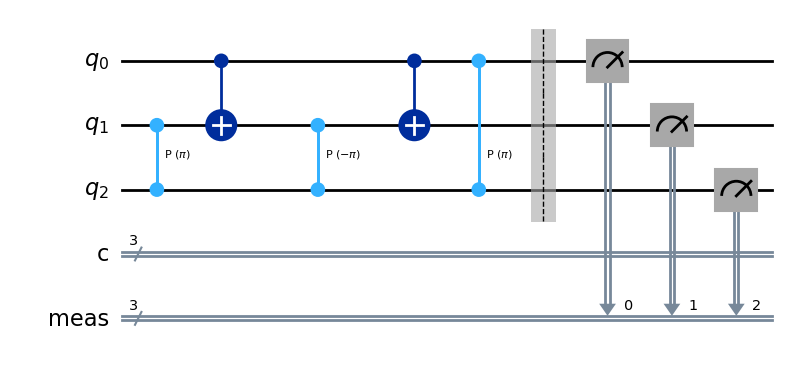

In [94]:
theta = np.pi
a = 0
b = 1
t = 2
qc1 = QuantumCircuit(3,3)
qc1.cp(theta,b,t)
qc1.cx(a,b)
qc1.cp(-theta,b,t)
qc1.cx(a,b)
qc1.cp(theta,a,t)
qc1.measure_all()
qc1.draw('mpl')



In [109]:
job = bq_client.run(qc1, device="mps.cpu")
stateVector = job.get_counts()
print(stateVector)

[BQ-PYTHON-SDK][INFO] - Submitted: Job ID: CrzW6y10JH6WDrz5, device: mps.cpu, run status: RUNNING, created on: 2026-03-29 18:20:35 UTC, estimated runtime: 5000 ms, estimated cost: $0.00, num qubits: 3, shots: 1024
{'000': 1.0}


In [116]:
sampler = SamplerV2()
job = sampler.run([qc1], shots=128)

# Perform an ideal simulation
result_ideal = job.result()
counts_ideal = result_ideal[0].data.meas.get_counts()
print('Counts(ideal):', counts_ideal)

Counts(ideal): {'000': 128}


In [135]:
# Transpile for simulator
simulator = AerSimulator()
qc1 = transpile(qc1, simulator)

# Run and get counts
result = simulator.run(qc1).result()
counts = result.get_counts(qc1)
#plot_histogram(counts, title='Bell-State counts')

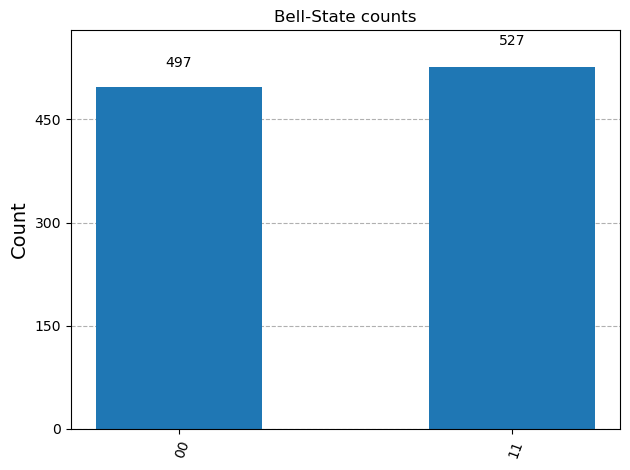

In [118]:
circ = QuantumCircuit(2)
circ.h(0)
circ.cx(0, 1)
circ.measure_all()

# Transpile for simulator
simulator = AerSimulator()
circ = transpile(circ, simulator)

# Run and get counts
result = simulator.run(circ).result()
counts = result.get_counts(circ)
plot_histogram(counts, title='Bell-State counts')

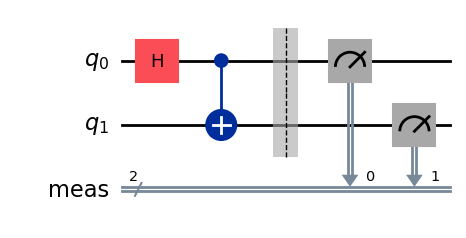

In [119]:
circ.draw('mpl')

In [120]:
# Run and get memory
result = simulator.run(circ, shots=10, memory=True).result()
memory = result.get_memory(circ)
print(memory)


['00', '11', '11', '00', '00', '00', '11', '00', '11', '00']


In [128]:
from mqt.qmap.plugins.qiskit.clifford_synthesis import optimize_clifford
from qiskit import QuantumCircuit

circ = QuantumCircuit(2)
circ.h(1)
circ.cx(0, 1)
circ.h(0)
circ.h(1)

circ_opt, results = optimize_clifford(circ)
result.get_statevector

<bound method Result.get_statevector of Result(backend_name='aer_simulator', backend_version='0.17.2', job_id='c02caa33-3ac9-4042-a4ae-e58fa3769ce0', success=True, results=[ExperimentResult(shots=10, success=True, meas_level=2, data=ExperimentResultData(counts={'0x3': 4, '0x0': 6}, memory=['0x0', '0x3', '0x3', '0x0', '0x0', '0x0', '0x3', '0x0', '0x3', '0x0']), header={'creg_sizes': [['meas', 2]], 'global_phase': 0.0, 'memory_slots': 2, 'n_qubits': 2, 'name': 'circuit-552', 'qreg_sizes': [['q', 2]], 'metadata': {}}, status=DONE, seed_simulator=1099980694, metadata={'time_taken': 0.000857003, 'num_bind_params': 1, 'parallel_state_update': 8, 'parallel_shots': 1, 'required_memory_mb': 0, 'input_qubit_map': [[1, 1], [0, 0]], 'method': 'stabilizer', 'device': 'CPU', 'num_qubits': 2, 'sample_measure_time': 1.5422e-05, 'active_input_qubits': [0, 1], 'num_clbits': 2, 'remapped_qubits': False, 'runtime_parameter_bind': False, 'max_memory_mb': 11925, 'noise': 'ideal', 'measure_sampling': True, '

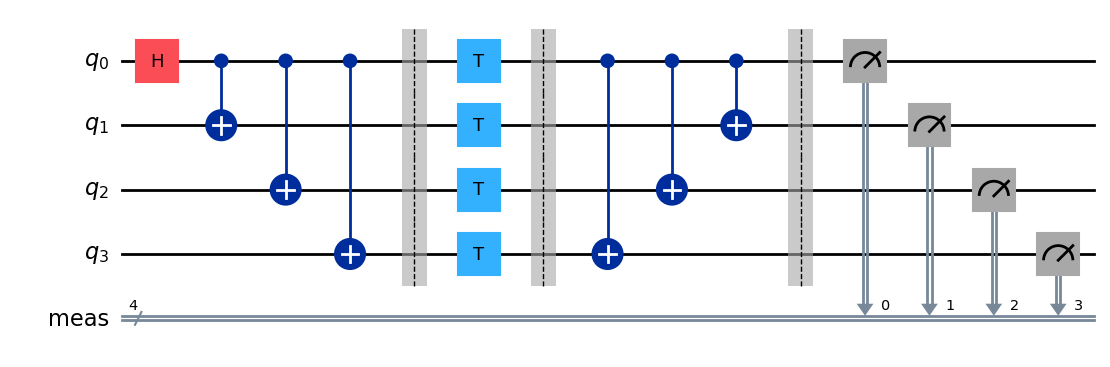

In [129]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(4)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)
qc.cx(0, 3)

qc.barrier()

qc.t(0)
qc.t(1)
qc.t(2)
qc.t(3)

qc.barrier()

qc.cx(0, 3)
qc.cx(0, 2)
qc.cx(0, 1)

qc.measure_all()

qc.draw(output="mpl")

In [130]:
from mqt.qmap.sc import Architecture

arch = Architecture(
    4,
    {
        (0, 1),
        (1, 0),
        (1, 2),
        (2, 1),
        (2, 3),
        (3, 2),
    },
)

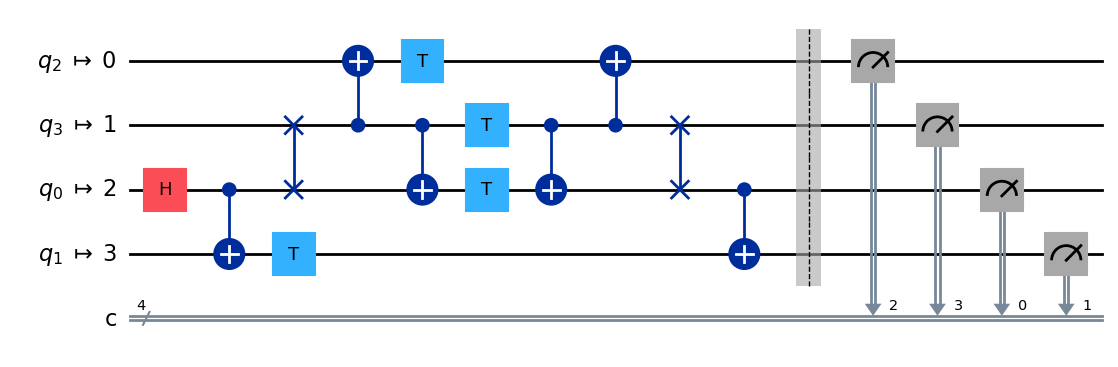

In [131]:
from mqt.qmap.plugins.qiskit.sc import compile_
from mqt.qmap.sc import Method

qc_mapped, res = compile_(qc, arch, method=Method.exact, post_mapping_optimizations=False)

qc_mapped.draw(output="mpl")

In [132]:
print(f"Additional SWAPs: {res.output.swaps}")
print(f"Runtime:          {res.time:f}")

Additional SWAPs: 2
Runtime:          0.049614


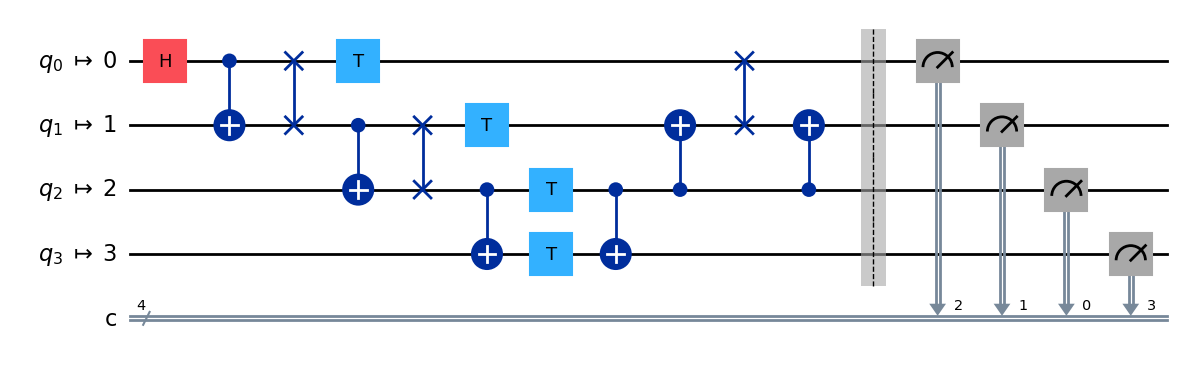

In [133]:
qc_mapped, res = compile_(qc, arch, method=Method.heuristic, post_mapping_optimizations=False)

qc_mapped.draw(output="mpl")

In [134]:
print(f"Additional SWAPs: {res.output.swaps}")
print(f"Runtime:          {res.time:f}")

Additional SWAPs: 3
Runtime:          0.000112
